<a href="https://colab.research.google.com/github/SanikaPatil1008/Deep_Learning/blob/main/Exp_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Baseline Training**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 784) / 255.0
x_test  = x_test.reshape(-1, 784) / 255.0

# Simple Deep Model
def create_model(lr):
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Train with fixed LR
model_fixed = create_model(0.01)
history_fixed = model_fixed.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    verbose=0
)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Adaptive LR**

In [ ]:
# Learning Rate Scheduler
def step_decay(epoch):
    initial_lr = 0.01
    drop = 0.5
    epochs_drop = 5
    return initial_lr * (drop ** (epoch // epochs_drop))

lr_scheduler = callbacks.LearningRateScheduler(step_decay, verbose=0)

# Train with LR decay
model_lr = create_model(0.01)
history_lr = model_lr.fit(
    x_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=[lr_scheduler],
    verbose=0
)

**Early Stopping + Comparison**

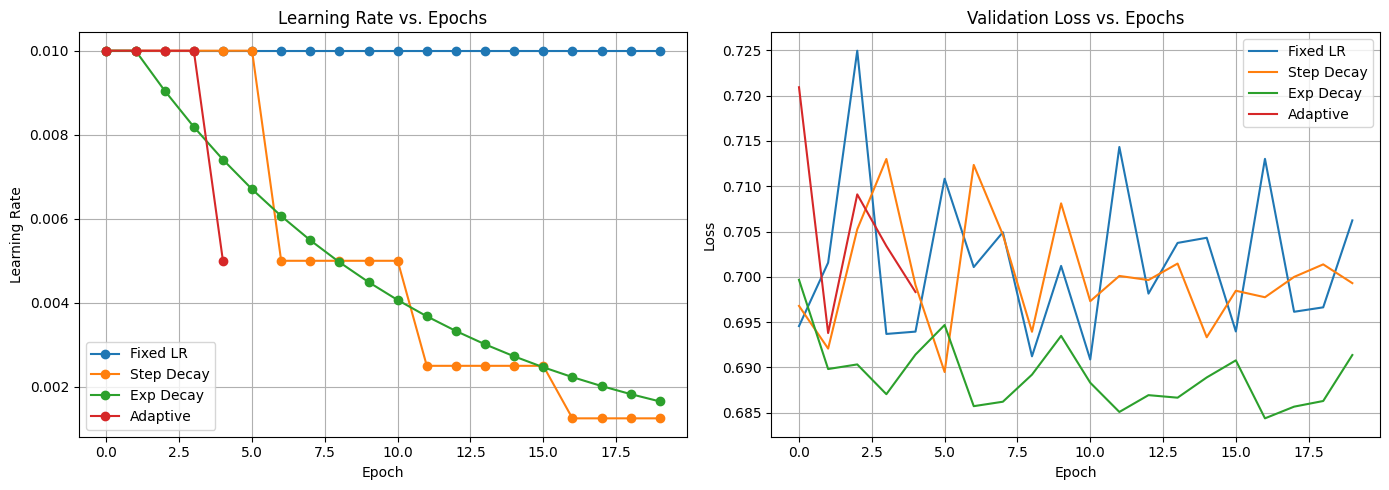

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
import matplotlib.pyplot as plt

# -------------------------------
# Data (simple & fast for demo)
# -------------------------------
x_train = np.random.random((1000, 20))
y_train = np.random.randint(0, 2, (1000,))
x_val   = np.random.random((200, 20))
y_val   = np.random.randint(0, 2, (200,))

EPOCHS = 20
INIT_LR = 0.01

# -------------------------------
# Model definition
# -------------------------------
def create_model(lr):
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(20,)),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy'
    )
    return model

# -------------------------------
# LR tracking callback
# -------------------------------
class LRHistory(callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.lrs = []

    def on_epoch_begin(self, epoch, logs=None):
        lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
        self.lrs.append(lr)

# -------------------------------
# Step Decay & Exp Decay
# -------------------------------
def step_decay(epoch):
    return INIT_LR * (0.5 ** (epoch // 5))

def exp_decay(epoch):
    return INIT_LR * np.exp(-0.1 * epoch)

# -------------------------------
# Train models
# -------------------------------
results = {}

def train(name, cb_list):
    model = create_model(INIT_LR)
    lr_hist = LRHistory()
    history = model.fit(
        x_train, y_train,
        epochs=EPOCHS,
        validation_data=(x_val, y_val),
        callbacks=[lr_hist] + cb_list,
        verbose=0
    )
    results[name] = (lr_hist.lrs, history.history['val_loss'])

# Fixed LR
train("Fixed LR", [])

# Step Decay
train("Step Decay", [callbacks.LearningRateScheduler(step_decay)])

# Exponential Decay
train("Exp Decay", [callbacks.LearningRateScheduler(exp_decay)])

# Adaptive LR + Early Stopping
adaptive_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, verbose=0
)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)
train("Adaptive", [adaptive_cb, early_stop])

# -------------------------------
# Visualization (same style)
# -------------------------------
plt.figure(figsize=(14,5))

# Learning Rate vs Epochs
plt.subplot(1,2,1)
for name, (lrs, _) in results.items():
    plt.plot(lrs, marker='o', label=name)
plt.title("Learning Rate vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid(True)

# Validation Loss vs Epochs
plt.subplot(1,2,2)
for name, (_, loss) in results.items():
    plt.plot(loss, label=name)
plt.title("Validation Loss vs. Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
